In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import kendalltau, spearmanr
from sklearn.metrics import r2_score

### Load data

In [2]:
data = np.load("fit_results.npz")
data_dict = {key: data[key] for key in data.files}
data_dict

{'e_disp_ref': array([-7.3749069e+01, -6.0493610e+01, -4.9847046e+01, ...,
        -1.7761080e-01, -1.1045760e-01, -7.1630083e-02], dtype=float32),
 'e_disp_xdm_init': array([-5.4157733e+02, -3.2826205e+02, -2.0600012e+02, ...,
        -1.1485225e-01, -7.0322968e-02, -4.5056336e-02], dtype=float32),
 'e_disp_xdm_final': array([-5.24989548e+01, -4.59248505e+01, -3.99048500e+01, ...,
        -1.14600286e-01, -7.02309161e-02, -4.50194702e-02], dtype=float32),
 'a1': array(0.66767925),
 'a2': array(0.86869568)}

### Plot

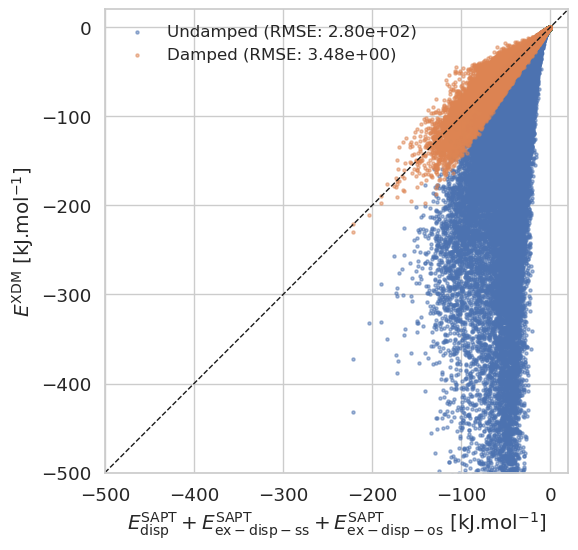

In [3]:
sns.set(style="whitegrid", font_scale=1.2)


def metrics(y_ref, y_pred):
    err = y_pred - y_ref
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    mse = np.mean(err)  # mean signed error (bias)
    tau, _ = kendalltau(y_ref, y_pred)
    rho, _ = spearmanr(y_ref, y_pred)
    r2 = r2_score(y_ref, y_pred)
    return rmse, mae, mse, tau, rho, r2


x = data_dict["e_disp_ref"]
y_init = np.asarray(data_dict["e_disp_xdm_init"])
y_final = data_dict["e_disp_xdm_final"]

rmse_i, mae_i, mse_i, tau_i, rho_i, r2_i = metrics(x, y_init)
rmse_f, mae_f, mse_f, tau_f, rho_f, r2_f = metrics(x, y_final)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    x,
    y_init,
    s=5,
    alpha=0.5,
    rasterized=True,
    label="Undamped (RMSE: {:.2e})".format(rmse_i),
)
ax.scatter(
    x,
    y_final,
    s=5,
    alpha=0.5,
    rasterized=True,
    label="Damped (RMSE: {:.2e})".format(rmse_f),
)

lims = [-500, 20]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel(
    r"$E^{\rm SAPT}_{\rm disp}+E^{\rm SAPT}_{\rm ex-disp-ss}+E^{\rm SAPT}_{\rm ex-disp-os}$ [kJ.mol$^{-1}$]"
)
ax.set_ylabel(r"$E^{\rm XDM}$ [kJ.mol$^{-1}$]")
ax.set_aspect("equal", adjustable="box")

ax.legend(frameon=False, loc="upper left", fontsize=12)
ax.grid(True)

plt.tight_layout()
plt.savefig("fit_results.pdf", dpi=1200, bbox_inches="tight")
plt.show()

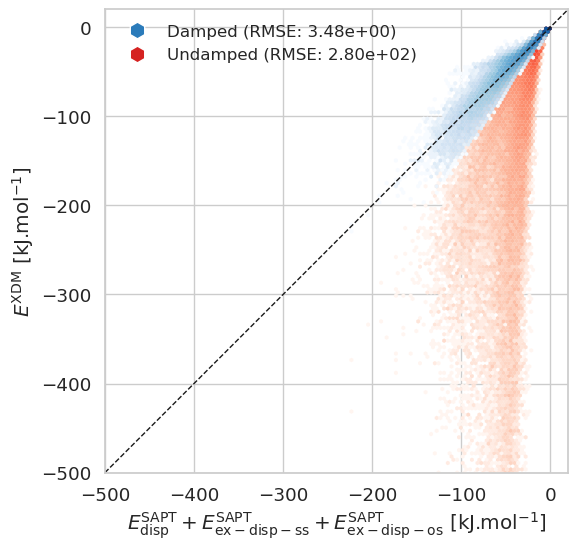

In [5]:
sns.set(style="whitegrid", font_scale=1.2)

x = data_dict["e_disp_ref"]
y_init = np.asarray(data_dict["e_disp_xdm_init"])
y_final = data_dict["e_disp_xdm_final"]

rmse_i, mae_i, mse_i, tau_i, rho_i, r2_i = metrics(x, y_init)
rmse_f, mae_f, mse_f, tau_f, rho_f, r2_f = metrics(x, y_final)

lims = [-500, 20]
extent = [lims[0], lims[1], lims[0], lims[1]]

fig, ax = plt.subplots(figsize=(6, 6))


ax.plot(lims, lims, "k--", lw=1)

hb1 = ax.hexbin(
    x,
    y_init,
    gridsize=125,
    extent=extent,
    cmap="Reds",
    bins="log",
    mincnt=1,
    alpha=1,
    linewidths=0.1,
    edgecolors="face",
)

hb2 = ax.hexbin(
    x,
    y_final,
    gridsize=125,
    extent=extent,
    cmap="Blues",
    bins="log",
    mincnt=1,
    alpha=1,
    linewidths=0.1,
    edgecolors="face",
)


ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_ylabel(r"$E^{\rm XDM}$ [kJ.mol$^{-1}$]")

ax.set_xlabel(
    r"$E^{\rm SAPT}_{\rm disp}+E^{\rm SAPT}_{\rm ex-disp-ss}+E^{\rm SAPT}_{\rm ex-disp-os}$ [kJ.mol$^{-1}$]"
)
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="h",
        color="w",
        label=f"Damped (RMSE: {rmse_f:.2e})",
        markerfacecolor=sns.color_palette("Blues", 6)[4],
        markersize=12,
    ),
    Line2D(
        [0],
        [0],
        marker="h",
        color="w",
        label=f"Undamped (RMSE: {rmse_i:.2e})",
        markerfacecolor=sns.color_palette("Reds", 6)[4],
        markersize=12,
    ),
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    loc="upper left",
    fontsize=12,
)

plt.tight_layout()

plt.savefig(
    "fit_results_hexbin.pdf",
    dpi=1200,
    bbox_inches="tight",
)

plt.show()